# Hypothesises testing code 


## Research Questions

**RQ1:** Is there a statistically significant positive relationship between a **country's GDP** and its **primary energy consumption and greenhouse gas emissions** over the period 2000–2024?

**RQ2:** Do the **top 10 highest-GDP countries** show a different **emissions-to-energy trend** compared to the **bottom 10 lowest-GDP countries** over the same period?

---
> **Note:** data cleaning and filtering code are the same as Lab 2, and some of the diagram are removed.
---

---
### Hypothesises of Research Question 1 (RQ1)

* **$H_{01}$ (Null Hypothesis):** There is no statistically significant relationship between GDP, primary energy consumption and greenhouse gas emissions.  

* **$H_{11}$ (Alternative Hypothesis):** There is a statistically significant relationship between GDP, primary energy consumption and greenhouse gas emissions.   

---

---
### Research Question 2 (RQ2)

* **$H_{03}$ (Null Hypothesis):** There is no statistically significant difference in the emissions-to-energy relationship between the top 10 highest-GDP countries and the bottom 10 lowest-GDP countries.

* **$H_{13}$ (Alternative Hypothesis):** There is a statistically significant difference in the emissions-to-energy relationship between the two groups.
---


### Cleaned Dataset Overview

The dataset has been processed and filtered. It contains the following key variables used for hypothesis testing:

| Column Name | Description | Data Type |
| :--- | :--- | :--- |
| `gdp` | Gross Domestic Product (Economic Output) | Float |
| `primary_energy_consumption` | Total energy used by the country | Float |
| `greenhouse_gas_emissions` | Total GHG emissions produced | Float |

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from scipy import stats
from statsmodels.formula.api import ols
import statsmodels.api as sm
warnings.filterwarnings('ignore')

# Global visual style
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [88]:
# ── Update path if needed ──────────────────────────────────────────────────
CSV_PATH = r'WorldEnergy.csv'
# ───────────────────────────────────────────────────────────────────────────

df_raw = pd.read_csv(CSV_PATH)

print(f"Dataset loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"Year range    : {int(df_raw['year'].min())} – {int(df_raw['year'].max())}")
print(f"Entities      : {df_raw['country'].nunique()} unique")
df_raw.head(3)

Dataset loaded: 23,195 rows × 130 columns
Year range    : 1900 – 2024
Entities      : 314 unique


,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN


In [89]:
# ── 2.1 Duplicate check ────────────────────────────────────────────────────
n_full_dup   = df_raw.duplicated().sum()
n_key_dup    = df_raw.duplicated(subset=['country', 'year']).sum()

print("=== Duplicate Check ===")
print(f"  Fully duplicate rows         : {n_full_dup}")
print(f"  Duplicate (country, year) pairs: {n_key_dup}")
if n_key_dup == 0:
    print("  ✅ No duplicate entries — each country-year pair is unique.")
else:
    print("  ⚠️  Duplicates found — investigation needed.")

=== Duplicate Check ===
  Fully duplicate rows         : 0
  Duplicate (country, year) pairs: 0
  ✅ No duplicate entries — each country-year pair is unique.


In [90]:
# ── 2.2 Year range sanity check ────────────────────────────────────────────
invalid_yr = df_raw[(df_raw['year'] < 1900) | (df_raw['year'] > 2025)]
print("=== Year Range Check ===")
print(f"  Expected: 1900–2024")
print(f"  Actual  : {int(df_raw['year'].min())} – {int(df_raw['year'].max())}")
print(f"  Rows outside valid range: {len(invalid_yr)}")
if len(invalid_yr) == 0:
    print("  ✅ All years within expected range.")

=== Year Range Check ===
  Expected: 1900–2024
  Actual  : 1900 – 2024
  Rows outside valid range: 0
  ✅ All years within expected range.


In [91]:
real_countries     = df_raw[df_raw['iso_code'].notna() & (df_raw['iso_code'].str.len() == 3)].copy()
aggregate_regions  = df_raw[df_raw['iso_code'].isna() | (df_raw['iso_code'] == '')].copy()

print(f"Real countries      : {real_countries['country'].nunique()}")
print(f"Aggregate/regional  : {aggregate_regions['country'].nunique()}")
print()
print("Sample aggregate entities (first 15):")
print(list(aggregate_regions['country'].unique()[:15]))

Real countries      : 220
Aggregate/regional  : 94

Sample aggregate entities (first 15):
['ASEAN (Ember)', 'Africa', 'Africa (EI)', 'Africa (EIA)', 'Africa (Ember)', 'Africa (Shift)', 'Asia', 'Asia & Oceania (EIA)', 'Asia (Ember)', 'Asia Pacific (EI)', 'Asia and Oceania (Shift)', 'Australia and New Zealand (EIA)', 'CIS (EI)', 'Central & South America (EIA)', 'Central America (EI)']


In [92]:
# ── Apply the time scope ───────────────────────────────────────────────────
START_YEAR, END_YEAR = 2000, 2024

rc_scoped = real_countries[(real_countries['year'] >= START_YEAR) &
                            (real_countries['year'] <= END_YEAR)].copy()

print(f"Scoped dataset: {rc_scoped.shape[0]:,} rows × {rc_scoped.shape[1]} columns")
print(f"Countries     : {rc_scoped['country'].nunique()}")
print(f"Year range    : {int(rc_scoped['year'].min())} – {int(rc_scoped['year'].max())}")

Scoped dataset: 5,383 rows × 130 columns
Countries     : 220
Year range    : 2000 – 2024


In [93]:
# ── Select numeric columns with ≤50% missing ───────────────────────────────
numeric_cols = rc_scoped.select_dtypes(include=np.number).columns.tolist()
miss_pct_scoped = (rc_scoped[numeric_cols].isnull().mean() * 100)
cols_to_keep = miss_pct_scoped[miss_pct_scoped <= 50].index.tolist()

print(f"Numeric columns total         : {len(numeric_cols)}")
print(f"Columns with ≤50% missing     : {len(cols_to_keep)}")
print(f"Dropped (>50% missing)        : {len(numeric_cols) - len(cols_to_keep)}")

Numeric columns total         : 128
Columns with ≤50% missing     : 64
Dropped (>50% missing)        : 64


In [94]:
# ── Pearson correlation matrix on retained columns ─────────────────────────
corr_matrix = rc_scoped[cols_to_keep].corr(method='pearson')

# Top 10 strongest positive pairs (excluding self-correlations)
pairs = (corr_matrix.unstack()
         .reset_index()
         .rename(columns={'level_0': 'Var1', 'level_1': 'Var2', 0: 'Correlation'}))
pairs = pairs[pairs['Var1'] < pairs['Var2']].sort_values('Correlation', ascending=False)

print("Top 10 strongest correlated pairs (Pearson r):")
print(pairs.head(10).to_string(index=False))

Top 10 strongest correlated pairs (Pearson r):
                  Var1                        Var2  Correlation
    electricity_demand      electricity_generation     0.999858
    fossil_electricity    greenhouse_gas_emissions     0.995529
    electricity_demand  primary_energy_consumption     0.989650
    electricity_demand          fossil_electricity     0.989497
electricity_generation  primary_energy_consumption     0.989436
electricity_generation          fossil_electricity     0.989078
    fossil_electricity  primary_energy_consumption     0.986419
   biofuel_electricity other_renewable_electricity     0.982538
      coal_electricity    greenhouse_gas_emissions     0.981689
 hydro_elec_per_capita  renewables_elec_per_capita     0.981574


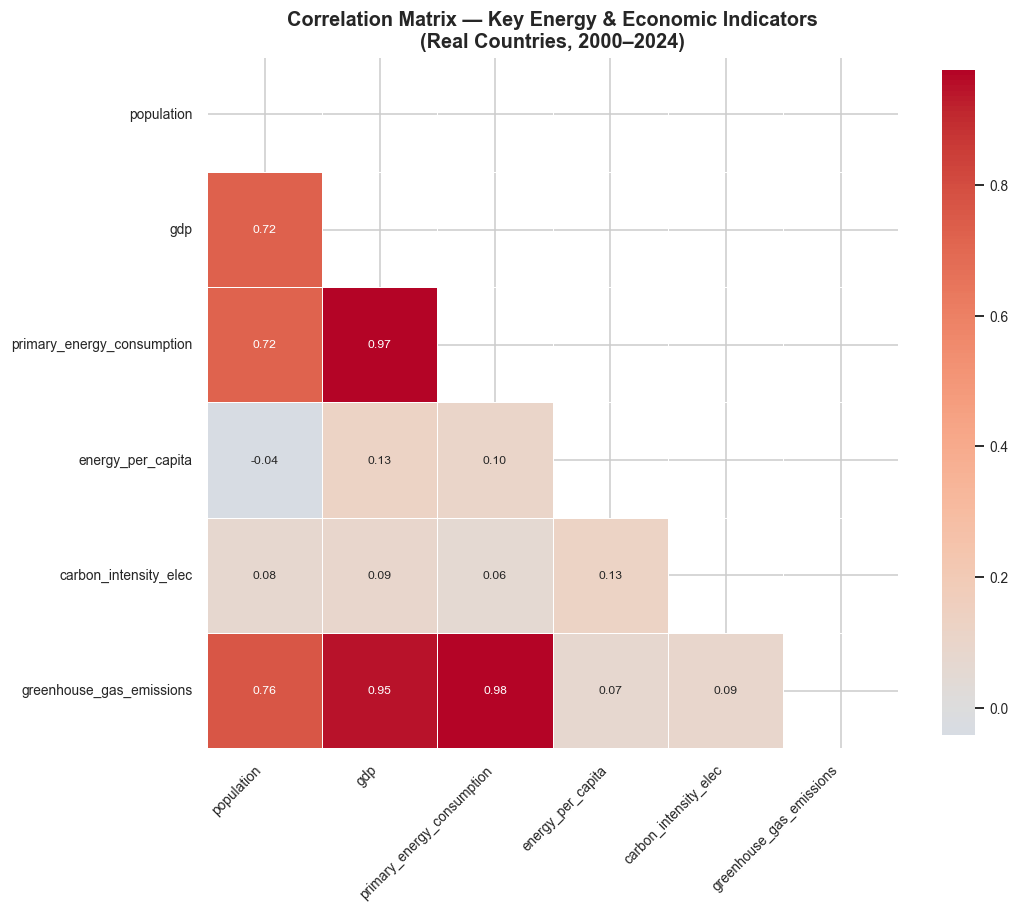

In [95]:
# ── Focused heatmap: key energy & economic indicators ───────────────────────
key_features = [
    'population', 'gdp', 'primary_energy_consumption', 'energy_per_capita',
    'renewables_share_energy', 'fossil_share_energy', 'coal_share_energy',
    'carbon_intensity_elec', 'greenhouse_gas_emissions',
    'solar_share_energy', 'wind_share_energy', 'hydro_share_energy', 'nuclear_share_energy'
]
key_features = [c for c in key_features if c in cols_to_keep]
corr_subset = rc_scoped[key_features].corr()

fig, ax = plt.subplots(figsize=(10, 9))
mask = np.triu(np.ones_like(corr_subset, dtype=bool))
sns.heatmap(corr_subset, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 8}, square=True, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Key Energy & Economic Indicators\n(Real Countries, 2000–2024)', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [96]:
# ── Decision: select the three most mutually correlated economic/emissions variables ─
print("=" * 65)
print("SCOPE DECISION")
print("=" * 65)
selected_trio = ['gdp', 'primary_energy_consumption', 'greenhouse_gas_emissions']
corr_trio = rc_scoped[selected_trio].corr()
print()
print("Correlation among selected trio:")
print(corr_trio.round(3))
print()
print("All three pairs have r > 0.94 — the strongest cluster in the dataset.")
print()
print("Selected scope:")
for col in selected_trio:
    miss = rc_scoped[col].isna().mean() * 100
    print(f"  {col:<38} Missing: {miss:.1f}%")
print()
print("These three variables directly address RQ1 and RQ2.")

SCOPE DECISION

Correlation among selected trio:
                              gdp  primary_energy_consumption  \
gdp                         1.000                       0.973   
primary_energy_consumption  0.973                       1.000   
greenhouse_gas_emissions    0.946                       0.976   

                            greenhouse_gas_emissions  
gdp                                            0.946  
primary_energy_consumption                     0.976  
greenhouse_gas_emissions                       1.000  

All three pairs have r > 0.94 — the strongest cluster in the dataset.

Selected scope:
  gdp                                    Missing: 29.6%
  primary_energy_consumption             Missing: 1.8%
  greenhouse_gas_emissions               Missing: 4.4%

These three variables directly address RQ1 and RQ2.


In [97]:
# ── Build the working DataFrame ─────────────────────────────────────────────
ID_COLS  = ['country', 'iso_code', 'year']
TRIO     = ['gdp', 'primary_energy_consumption', 'greenhouse_gas_emissions']

df_work = rc_scoped[ID_COLS + TRIO].copy()
print(f"Working DataFrame shape (before cleaning): {df_work.shape}")
print()
print("Missing values before cleaning:")
print(df_work[TRIO].isnull().sum().to_string())

Working DataFrame shape (before cleaning): (5383, 6)

Missing values before cleaning:
gdp                           1593
primary_energy_consumption      99
greenhouse_gas_emissions       236


In [98]:
# ── Step 6a: Sort by country + year ─────────────────────────────────────────
# Critical: interpolation assumes chronological order within each country group
df_work = df_work.sort_values(['country', 'year']).reset_index(drop=True)
print("✅ Sorted by country + year.")

✅ Sorted by country + year.


In [99]:
# ── Step 6b: First-pass interpolation (limit=2 consecutive gaps) ────────────
# 'limit=2' handles countries with up to 2-year reporting gaps (e.g. small island nations)
# 'limit_direction=both' fills gaps at the start and end of a series too
for col in TRIO:
    df_work[col] = (df_work
                    .groupby('country')[col]
                    .transform(lambda x: x.interpolate(
                        method='linear', limit_direction='both', limit=2)))

print("Missing after first-pass interpolation:")
print(df_work[TRIO].isnull().sum().to_string())

Missing after first-pass interpolation:
gdp                           1313
primary_energy_consumption      53
greenhouse_gas_emissions       158


In [100]:
# ── Step 6c: Replace zero and negative values with NaN ─────────────────────
# Zero or negative values are physically impossible for these variables:
#   - GDP cannot be 0 or negative (would indicate no economic activity)
#   - Primary energy consumption cannot be <= 0
#   - Greenhouse gas emissions <= 0 would imply net carbon sink (not in this dataset context)

zero_counts = {}
for col in TRIO:
    n_zero = (df_work[col] <= 0).sum()
    zero_counts[col] = n_zero
    df_work.loc[df_work[col] <= 0, col] = np.nan
print(zero_counts)   
print("Zero/negative values replaced with NaN:")
for col, n in zero_counts.items():
    print(f"  {col:<40}: {n} values replaced")

{'gdp': np.int64(0), 'primary_energy_consumption': np.int64(97), 'greenhouse_gas_emissions': np.int64(46)}
Zero/negative values replaced with NaN:
  gdp                                     : 0 values replaced
  primary_energy_consumption              : 97 values replaced
  greenhouse_gas_emissions                : 46 values replaced


In [101]:
# ── Step 6d: Second-pass interpolation (no limit — structural gaps only) ────
for col in TRIO:
    df_work[col] = (df_work
                    .groupby('country')[col]
                    .transform(lambda x: x.interpolate(
                        method='linear', limit_direction='both')))

print("Missing after second-pass interpolation:")
print(df_work[TRIO].isnull().sum().to_string())

Missing after second-pass interpolation:
gdp                           1313
primary_energy_consumption      97
greenhouse_gas_emissions       170


In [102]:
# ── Step 6e: Drop rows with any remaining missing values ────────────────────
rows_before = len(df_work)
df_clean = df_work.dropna(subset=TRIO).copy()
rows_after = len(df_clean)

print(f"Rows before drop : {rows_before:,}")
print(f"Rows after drop  : {rows_after:,}")
print(f"Rows removed     : {rows_before - rows_after:,}")
print(f"Countries retained: {df_clean['country'].nunique()}")

Rows before drop : 5,383
Rows after drop  : 4,070
Rows removed     : 1,313
Countries retained: 165


### Grouped Data in `df_box`

The dataset has been categorized into two groups based on GDP ranking to compare their emissions-to-energy profiles.

| Grouping | Count | Description |
| :--- | :---: | :--- |
| **Top 10 GDP** | 10 | Countries with the highest economic output. |
| **Bottom 10 GDP** | 10 | Countries with the lowest economic output. |

In [103]:
# ── Rank countries by average GDP (2000–2024) ───────────────────────────────
avg_df = (df_clean
          .groupby('country')[TRIO]
          .mean()
          .reset_index())

top_10_countries    = avg_df.nlargest(10,  'gdp')['country'].tolist()
bottom_10_countries = avg_df.nsmallest(10, 'gdp')['country'].tolist()

print("Top 10 GDP Countries (avg 2000–2024):")
print(top_10_countries)
print()
print("Bottom 10 GDP Countries (avg 2000–2024):")
print(bottom_10_countries)

Top 10 GDP Countries (avg 2000–2024):
['United States', 'China', 'India', 'Japan', 'Germany', 'Russia', 'Brazil', 'France', 'Indonesia', 'United Kingdom']

Bottom 10 GDP Countries (avg 2000–2024):
['Sao Tome and Principe', 'Dominica', 'Comoros', 'Saint Lucia', 'Seychelles', 'Djibouti', 'Guinea-Bissau', 'Cape Verde', 'Gambia', 'Liberia']


In [104]:
# ── Build grouped DataFrame ──────────────────────────────────────────────────
df_grouped = df_clean.copy()
df_grouped['group'] = np.where(
    df_grouped['country'].isin(top_10_countries), 'Top 10 GDP',
    np.where(df_grouped['country'].isin(bottom_10_countries), 'Bottom 10 GDP', 'Other')
)
df_box = df_grouped[df_grouped['group'].isin(['Top 10 GDP', 'Bottom 10 GDP'])].copy()

print(f"Top 10 group rows    : {(df_box['group']=='Top 10 GDP').sum()}")
print(f"Bottom 10 group rows : {(df_box['group']=='Bottom 10 GDP').sum()}")


Top 10 group rows    : 250
Bottom 10 group rows : 240


---
## RQ1 – Linear Regression & Pearson Correlation

**Hypotheses:**
- **H₀:** There is no linear relationship between GDP and Energy/GHG (r = 0)
- **H₁:** There is a significant linear relationship (r ≠ 0)

**Significance level:** α = 0.05

In [105]:
gdp    = df_clean['gdp'].values
energy = df_clean['primary_energy_consumption'].values
ghg    = df_clean['greenhouse_gas_emissions'].values

# ── GDP vs Primary Energy Consumption ──────────────────────────────
r_energy, p_energy = stats.pearsonr(gdp, energy)
slope_e, intercept_e, r_val_e, p_val_e, se_e = stats.linregress(gdp, energy)

print('━' * 55)
print('  GDP  ↔  Primary Energy Consumption')
print('━' * 55)
print(f'  Pearson r     : {r_energy:.4f}')
print(f'  p-value       : {p_energy:.4e}')
print(f'  Regression    : y = {slope_e:.4e}·x + {intercept_e:.4f}')
print(f'  Interpretation: {"✔ Reject H₀ – Significant relationship" if p_energy < 0.05 else "✘ Fail to reject H₀"}')

# ── GDP vs Greenhouse Gas Emissions ────────────────────────────────
r_ghg, p_ghg = stats.pearsonr(gdp, ghg)
slope_g, intercept_g, r_val_g, p_val_g, se_g = stats.linregress(gdp, ghg)

print()
print('━' * 55)
print('  GDP  ↔  Greenhouse Gas Emissions')
print('━' * 55)
print(f'  Pearson r     : {r_ghg:.4f}')
print(f'  p-value       : {p_ghg:.4e}')
print(f'  Regression    : y = {slope_g:.4e}·x + {intercept_g:.4f}')
print(f'  Interpretation: {"✔ Reject H₀ – Significant relationship" if p_ghg < 0.05 else "✘ Fail to reject H₀"}')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  GDP  ↔  Primary Energy Consumption
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Pearson r     : 0.9732
  p-value       : 0.0000e+00
  Regression    : y = 1.6435e-09·x + -94.8771
  Interpretation: ✔ Reject H₀ – Significant relationship

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  GDP  ↔  Greenhouse Gas Emissions
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Pearson r     : 0.9435
  p-value       : 0.0000e+00
  Regression    : y = 1.6010e-10·x + -22.9552
  Interpretation: ✔ Reject H₀ – Significant relationship


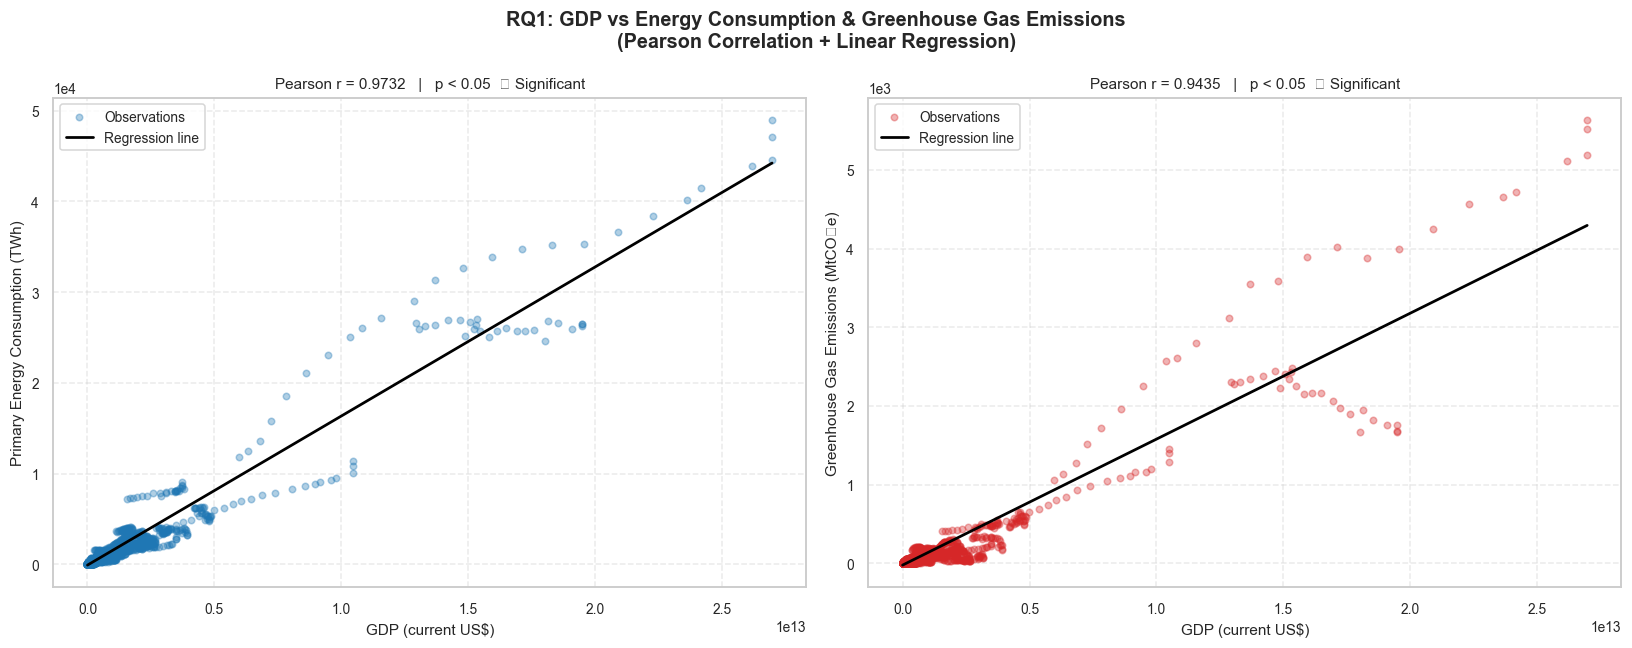

Plot saved → RQ1_scatter_regression.png


In [106]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(
    'RQ1: GDP vs Energy Consumption & Greenhouse Gas Emissions\n'
    '(Pearson Correlation + Linear Regression)',
    fontsize=13, fontweight='bold'
)

plot_configs = [
    (axes[0], energy, slope_e, intercept_e, r_energy, p_energy,
     'Primary Energy Consumption (TWh)', '#1f77b4'),
    (axes[1], ghg,   slope_g, intercept_g, r_ghg,   p_ghg,
     'Greenhouse Gas Emissions (MtCO₂e)', '#d62728'),
]

for ax, y_vals, slope, intercept, r_val, p_val, ylabel, color in plot_configs:
    ax.scatter(gdp, y_vals, alpha=0.35, s=18, color=color, label='Observations')

    x_line = np.linspace(gdp.min(), gdp.max(), 300)
    ax.plot(x_line, slope * x_line + intercept,
            color='black', linewidth=1.8, label='Regression line')

    sig = 'p < 0.05  ✔ Significant' if p_val < 0.05 else 'p ≥ 0.05  ✘ Not Significant'
    ax.set_title(f'Pearson r = {r_val:.4f}   |   {sig}', fontsize=10)
    ax.set_xlabel('GDP (current US$)', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.legend(fontsize=9)
    ax.ticklabel_format(style='sci', axis='both', scilimits=(0, 0))
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('RQ1_scatter_regression.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved → RQ1_scatter_regression.png')

---
##  RQ2 – One-Way ANOVA
### Emissions-to-Energy Ratio: Top 10 vs Bottom 10 GDP Countries

**Hypotheses:**
- **H₀:** There is no statistically significant difference in the emissions-to-energy relationship between the top 10 highest-GDP countries and the bottom 10 lowest-GDP countries. 
- **H₁:** There is a statistically significant difference in the emissions-to-energy relationship between the two groups.

**Significance level:** α = 0.05


#  ANOVA justification

### Step 1: Checking for repeated observations per country

Before applying ANOVA, it is important to verify whether the dataset contains repeated measurements for each country over time. Since the dataset spans 2000–2024, each country may appear multiple times, which violates the independence assumption of ANOVA.

---
> **The Rule of ANOVA:**  Each data point must be independent of the others. This means the performance or score of one subject should not influence another.
---


In [107]:
counts = df_box.groupby('country').size()
print(counts.describe())
print("❌ raw data: Each country contributes multiple observations across time, violating the independence assumption required for ANOVA")

count    20.000000
mean     24.500000
std       0.512989
min      24.000000
25%      24.000000
50%      24.500000
75%      25.000000
max      25.000000
dtype: float64
❌ raw data: Each country contributes multiple observations across time, violating the independence assumption required for ANOVA


### Step 2: Examining number of observations per group (raw data)

This step computes the emissions-to-energy ratio and examines the number of observations per group. The results indicate multiple observations per country due to the time-series nature of the dataset (2000–2024), which violates the independence assumption required for ANOVA. Therefore, aggregation is required in the next step.

In [108]:
Emissions='greenhouse_gas_emissions'
Energy='primary_energy_consumption'
df_box['ratio'] = df_box[Emissions] / df_box[Energy]
print(df_box.groupby('group')['ratio'].count())
print("each country contributes many rows and violates ANOVA assumption")

group
Bottom 10 GDP    240
Top 10 GDP       250
Name: ratio, dtype: int64
each country contributes many rows and violates ANOVA assumption


### Step 3: Aggregating emissions-to-energy ratio by country

To satisfy the independence assumption of ANOVA, the emissions-to-energy ratio is averaged across the study period (2000–2024) for each country. This ensures that each country contributes a single observation to the analysis.

In [109]:
df_mean = (
    df_box
    .groupby(['country', 'group'])['ratio']
    .mean()
    .reset_index()
)

### Step 4: Verifying the aggregated dataset structure

After aggregation, each country should appear only once, ensuring independence of observations across groups.

In [110]:
print(df_mean.groupby('group').size())
print("Satistified the ANOVA assumption rule")

group
Bottom 10 GDP    10
Top 10 GDP       10
dtype: int64
Satistified the ANOVA assumption rule


### Step 5 :Normality Test (Shapiro-Wilk)

The Shapiro-Wilk test was conducted to assess whether the emissions-to-energy ratio is normally distributed within each GDP group. A p-value greater than 0.05 indicates that the data does not significantly deviate from normality.

In [111]:
# Split groups
top_group = df_mean[df_mean['group'] == 'Top 10 GDP']['ratio']
bottom_group = df_mean[df_mean['group'] == 'Bottom 10 GDP']['ratio']

# Shapiro-Wilk test
stat_top, p_top = stats.shapiro(top_group)
stat_bottom, p_bottom = stats.shapiro(bottom_group)

print("Top 10 GDP group:")
print("Statistic =", stat_top, ", p-value =", p_top)

print("\nBottom 10 GDP group:")
print("Statistic =", stat_bottom, ", p-value =", p_bottom)

print("normality assumption satisfied ✅ p>0.05")

Top 10 GDP group:
Statistic = 0.9406685183708846 , p-value = 0.5604759467086904

Bottom 10 GDP group:
Statistic = 0.9781359211598787 , p-value = 0.9544161009345571
normality assumption satisfied ✅ p>0.05


### Step 6: Homogeneity of Variance (Levene’s Test)

Levene’s test was performed to examine whether the variances of the emissions-to-energy ratio are equal across the two GDP groups. A p-value greater than 0.05 indicates that the assumption of homogeneity of variance is satisfied.

In [112]:
from scipy.stats import levene

stat_lev, p_lev = levene(top_group, bottom_group)

print("Levene’s Test:")
print("Statistic =", stat_lev, ", p-value =", p_lev)
print("Variances are equal across groups ✅ p>0.05")

Levene’s Test:
Statistic = 0.06901521171211315 , p-value = 0.7957593410052509
Variances are equal across groups ✅ p>0.05


#  Performing one-way ANOVA

A one-way ANOVA is conducted to test whether there is a statistically significant difference in the mean emissions-to-energy ratio between the Top 10 and Bottom 10 GDP country groups.

In [113]:

model = ols('ratio ~ C(group)', data=df_mean).fit() # group contains 10 high GDP and 10 low GDP groups
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)
print()
print("........................................")
print("Fail to reject the null hypothesis: no significant difference between groups.")
print("........................................")

            sum_sq    df         F    PR(>F)
C(group)  0.000006   1.0  0.005465  0.941887
Residual  0.019000  18.0       NaN       NaN

........................................
Fail to reject the null hypothesis: no significant difference between groups.
........................................


## Final Statistical Assumption Testing and ANOVA Results

Prior to conducting the ANOVA test, the key assumptions of normality and homogeneity of variance were assessed.

---
### ANOVA Test
A one-way ANOVA was conducted to determine whether there is a statistically significant difference in the emissions-to-energy ratio between the two GDP groups. Since both assumptions were satisfied, the results of the ANOVA are considered valid.

---
---
### Normality Test (Shapiro-Wilk)
The Shapiro-Wilk test was applied to the residuals of the model to assess whether the emissions-to-energy ratio is normally distributed. The results showed that the assumption of normality was satisfied (p > 0.05), indicating no significant deviation from a normal distribution.

---
---
### Homogeneity of Variance (Levene’s Test)
Levene’s test was used to assess whether the variances between the Top 10 GDP and Bottom 10 GDP groups were equal. The result (p > 0.05) confirmed that the assumption of equal variances was met.

---
---
### Conclusion
Based on the ANOVA results, the null hypothesis is not rejected depending on the p-value > 0.05. Overall, the analysis confirms there are not a statistically significant difference exists between the two groups.

---